In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

import pmdarima as pm


In [48]:
df.describe

<bound method NDFrame.describe of               id       date  store_nbr     family     sales  onpromotion
12            12 2013-01-01          1  GROCERY I     0.000            0
45            45 2013-01-01         10  GROCERY I     0.000            0
78            78 2013-01-01         11  GROCERY I     0.000            0
111          111 2013-01-01         12  GROCERY I     0.000            0
144          144 2013-01-01         13  GROCERY I     0.000            0
...          ...        ...        ...        ...       ...          ...
3000735  3000735 2017-08-15         54  GROCERY I  4235.000           44
3000768  3000768 2017-08-15          6  GROCERY I  4334.000           33
3000801  3000801 2017-08-15          7  GROCERY I  3678.000           34
3000834  3000834 2017-08-15          8  GROCERY I  4035.000           34
3000867  3000867 2017-08-15          9  GROCERY I  6630.383           62

[90936 rows x 6 columns]>

In [2]:
data = pd.read_csv('train.csv')
data.head()


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
# 1. Agregasi baris mentah -> total sales harian
data['date'] = pd.to_datetime(data['date'])
daily_group = data.groupby('date')['sales'].sum()   # Series, index = tanggal

# 2. Bulanan
monthly_group = daily_group.resample('ME').sum()     # 'ME' = month end

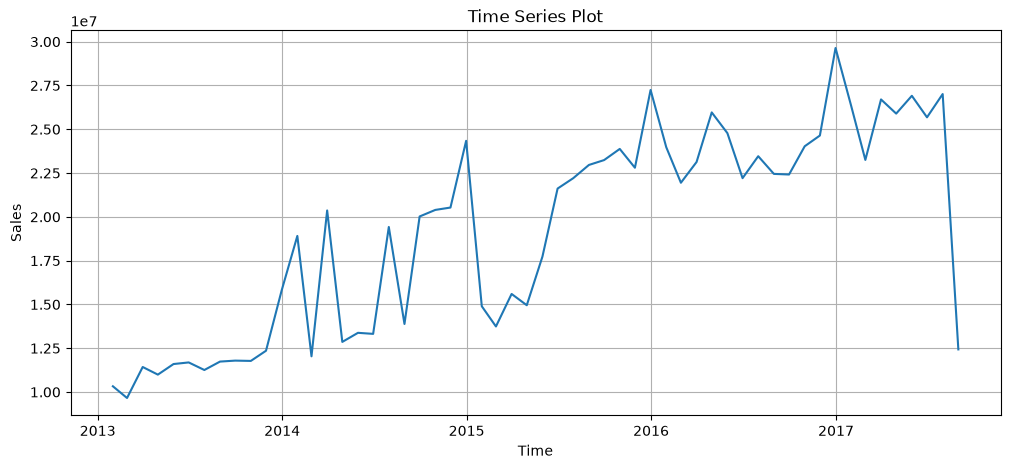

In [4]:
plt.figure(figsize=(12,5))
plt.plot(monthly_group)
plt.title("Time Series Plot")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.grid(True)
plt.show()


In [5]:
monthly_group = monthly_group.interpolate()
monthly_group = monthly_group.iloc[:-1]

In [6]:
adf = adfuller(monthly_group)
print("ADF Statistic:", adf[0])
print("p-value:", adf[1])

if adf[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary — Differencing Needed")


ADF Statistic: -1.5561885728668223
p-value: 0.5055554852721772
Series is NOT Stationary — Differencing Needed


ADF Statistic: -11.83445723505216
p-value: 7.85063030048067e-22
Series is Stationary


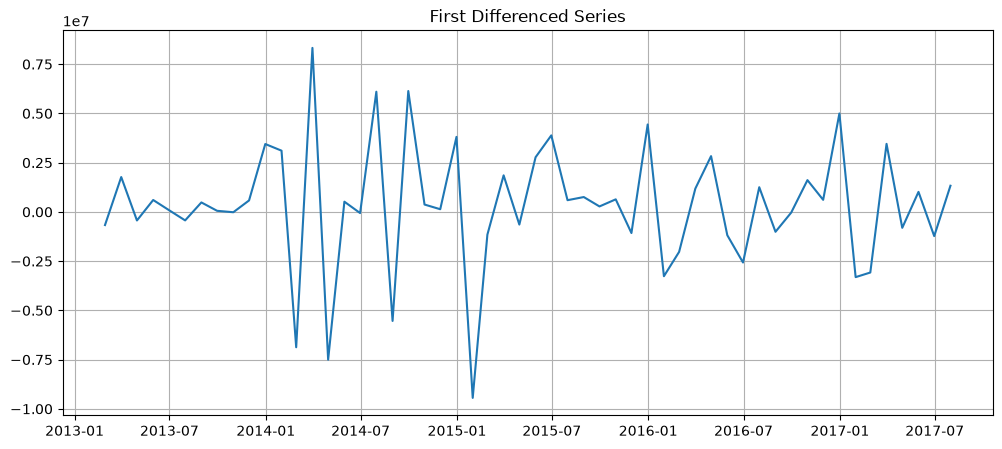

In [7]:
# First differencing
monthly_diff = monthly_group.diff().dropna()

# Cek ulang ADF
adf = adfuller(monthly_diff)
print("ADF Statistic:", adf[0])
print("p-value:", adf[1])
if adf[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary — Differencing Needed")

# Plot hasilnya
plt.figure(figsize=(12,5))
plt.plot(monthly_diff)
plt.title("First Differenced Series")
plt.grid(True)
plt.show()

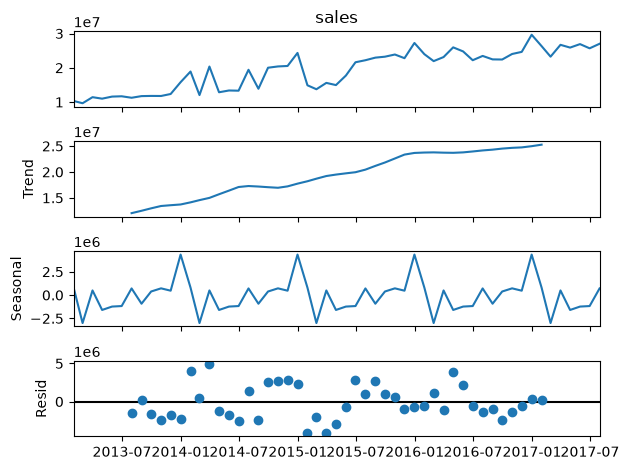

In [8]:
decomp = seasonal_decompose(monthly_group, model="additive", period=12)
decomp.plot()
plt.show()


In [9]:
train = monthly_group[:-12]
test = monthly_group[-12:]


In [10]:
model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1383.451, Time=0.40 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1386.786, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1380.212, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1380.265, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1385.149, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1378.847, Time=0.03 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1379.883, Time=0.04 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1381.164, Time=0.10 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1380.455, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1380.411, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1379.007, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=1382.401, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[12]             : AIC=1378.097, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12]             : AIC=1379.215, Time=0.04 sec
 ARIMA(1,1,0)(0,0,1

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   43
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -687.048
Date:                Wed, 01 Jul 2026   AIC                           1378.097
Time:                        08:47:24   BIC                           1381.572
Sample:                    01-31-2013   HQIC                          1379.370
                         - 07-31-2016                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3996      0.096     -4.179      0.000      -0.587      -0.212
sigma2      9.341e+12   1.15e-15   8.14e+27      0.000    9.34e+12    9.34e+12
===================================================================================
Ljung-Box (L1) (Q):                   0.75   Jarque-Bera (JB):                 2.04
Prob(Q):                              0.39   Prob(JB):                         0.36
Heteroskedasticity (H):               0.73   Skew:                            -0.53
Prob(H) (two-sided):                  0.57   Kurtosis:                         3.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.03e+44. Standard errors may be unstable.
"""

In [11]:
model2 = pm.auto_arima(train, seasonal=True, m=12, D=1, stepwise=True)
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   43
Model:             SARIMAX(2, 0, 2)x(0, 1, 2, 12)   Log Likelihood                -508.174
Date:                            Wed, 01 Jul 2026   AIC                           1032.347
Time:                                    08:47:33   BIC                           1043.819
Sample:                                01-31-2013   HQIC                          1036.087
                                     - 07-31-2016                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   4.451e+06   5.97e-08   7.46e+13      0.000    4.45e+06    4.45e+06
ar.L1          0.7557      0.271      2.785      0.005       0.224       1.288
ar.L2         -0.6326      0.212     -2.979      0.003      -1.049      -0.216
ma.L1         -0.5823      0.172     -3.383      0.001      -0.920      -0.245
ma.L2          0.9546      0.284      3.357      0.001       0.397       1.512
ma.S.L12      -0.3222      0.394     -0.819      0.413      -1.094       0.449
ma.S.L24      -0.2706      0.392     -0.691      0.490      -1.038       0.497
sigma2      1.155e+13   1.86e-14    6.2e+26      0.000    1.15e+13    1.15e+13
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 2.89
Prob(Q):                              0.72   Prob(JB):                         0.24
Heteroskedasticity (H):               0.46   Skew:                            -0.73
Prob(H) (two-sided):                  0.24   Kurtosis:                         3.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.06e+43. Standard errors may be unstable.
"""

In [12]:
forecast = model.predict(n_periods=12)
forecast = pd.Series(forecast, index=test.index)
forecast

date
2016-08-31    2.296177e+07
2016-09-30    2.316194e+07
2016-10-31    2.308195e+07
2016-11-30    2.311392e+07
2016-12-31    2.310114e+07
2017-01-31    2.310625e+07
2017-02-28    2.310421e+07
2017-03-31    2.310502e+07
2017-04-30    2.310470e+07
2017-05-31    2.310483e+07
2017-06-30    2.310477e+07
2017-07-31    2.310479e+07
Freq: ME, dtype: float64

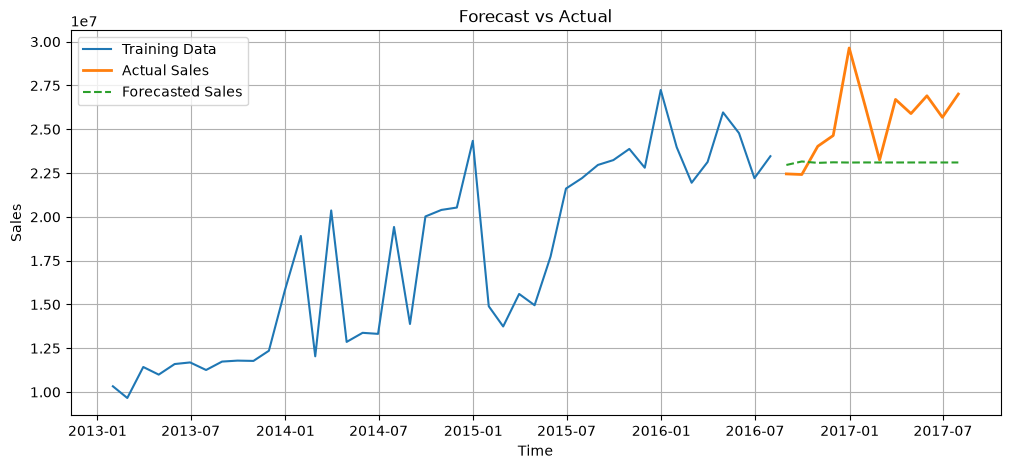

In [13]:
plt.figure(figsize=(12,5))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Sales', linewidth=2)
plt.plot(forecast, label='Forecasted Sales', linestyle="--")
plt.title("Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape, "%")


MAE: 2526611.9417971144
MSE: 9529576261000.26
RMSE: 3087001.1760607185
MAPE: 9.464002750517391 %


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_15608\720967947.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(test.index[-1], periods=25, freq="M")[1:]


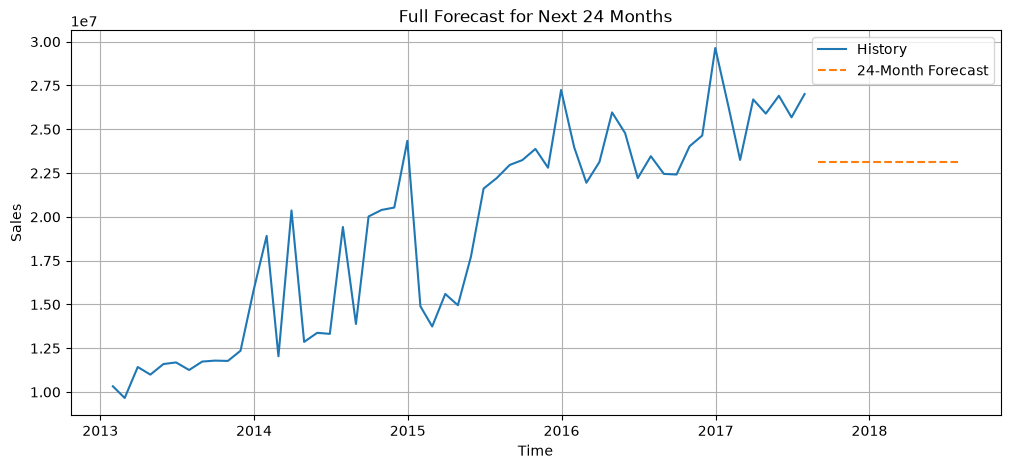

In [15]:
future = model.predict(n_periods=24)
future_index = pd.date_range(test.index[-1], periods=25, freq="M")[1:]

future_series = pd.Series(future, index=future_index)

plt.figure(figsize=(12,5))
plt.plot(monthly_group, label="History")
plt.plot(future_series, label="24-Month Forecast", linestyle="--")
plt.title("Full Forecast for Next 24 Months")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
model_seasonal = pm.auto_arima(train, seasonal=True, m=12, D=1,
                               trace=True, error_action='ignore',
                               suppress_warnings=True, stepwise=True)
print(model_seasonal.summary())

fc_seasonal = model_seasonal.predict(n_periods=len(test))
mape_s = np.mean(np.abs((test.values - fc_seasonal) / test.values)) * 100
print(f"MAPE musiman: {mape_s:.2f}%")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=1032.786, Time=0.82 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1033.539, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1034.391, Time=0.09 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1035.398, Time=0.08 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1060.708, Time=0.02 sec
 ARIMA(2,0,2)(0,1,1)[12] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(2,0,2)(1,1,0)[12] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(2,0,2)(2,1,1)[12] intercept   : AIC=1033.264, Time=1.04 sec
 ARIMA(2,0,2)(1,1,2)[12] intercept   : AIC=1033.741, Time=1.02 sec
 ARIMA(2,0,2)(0,1,0)[12] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(2,0,2)(0,1,2)[12] intercept   : AIC=1032.347, Time=0.63 sec
 ARIMA(1,0,2)(0,1,2)[12] intercept   : AIC=1033.505, Time=0.32 sec
 ARIMA(2,0,1)(0,1,2)[12] intercept   : AIC=1034.320, Time=0.70 sec
 ARIMA(3,0,2)(0,1,2)[12] intercept   : AIC=1036.542, Time=0.59 sec
 ARIMA(2,0,3)(0,1,2)[12] intercept

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def hitung_error(test, pred):
    mae  = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))
    mape = np.mean(np.abs((test.values - np.array(pred)) / test.values)) * 100
    return mae, rmse, mape

hasil = {}

# 1. Naive — ulang nilai terakhir train
pred_naive = np.repeat(train.iloc[-1], len(test))
hasil['Naive'] = hitung_error(test, pred_naive)

# 2. Seasonal Naive — ambil 12 bulan terakhir train, ulang
pred_snaive = np.array([train.iloc[-12 + (i % 12)] for i in range(len(test))])
hasil['Seasonal Naive'] = hitung_error(test, pred_snaive)

# 3. Holt-Winters (trend + musiman)
hw = ExponentialSmoothing(train, trend='add', seasonal='add',
                          seasonal_periods=12).fit()
pred_hw = hw.forecast(len(test))
hasil['Holt-Winters'] = hitung_error(test, pred_hw)

# 4. SARIMA non-musiman (model auto_arima kamu yang lama)
pred_sarima = model.predict(n_periods=len(test))
hasil['SARIMA (non-musiman)'] = hitung_error(test, pred_sarima)

# 5. SARIMA musiman dipaksa
model_s = pm.auto_arima(train, seasonal=True, m=12, D=1,
                        error_action='ignore', suppress_warnings=True)
pred_s = model_s.predict(n_periods=len(test))
hasil['SARIMA (musiman)'] = hitung_error(test, pred_s)

# Rangkum jadi tabel
tabel = pd.DataFrame(hasil, index=['MAE', 'RMSE', 'MAPE']).T
tabel = tabel.sort_values('MAPE')
print(tabel.round(2))

                             MAE        RMSE   MAPE
Seasonal Naive        1847387.08  2222531.34   7.07
Holt-Winters          2093284.44  2352632.90   8.38
Naive                 2329245.11  2829764.39   8.76
SARIMA (non-musiman)  2526611.94  3087001.18   9.46
SARIMA (musiman)      2790975.29  2897240.76  11.14


In [18]:
# Samakan index forecast dengan tanggal test
fc_seasonal = pd.Series(fc_seasonal, index=test.index)

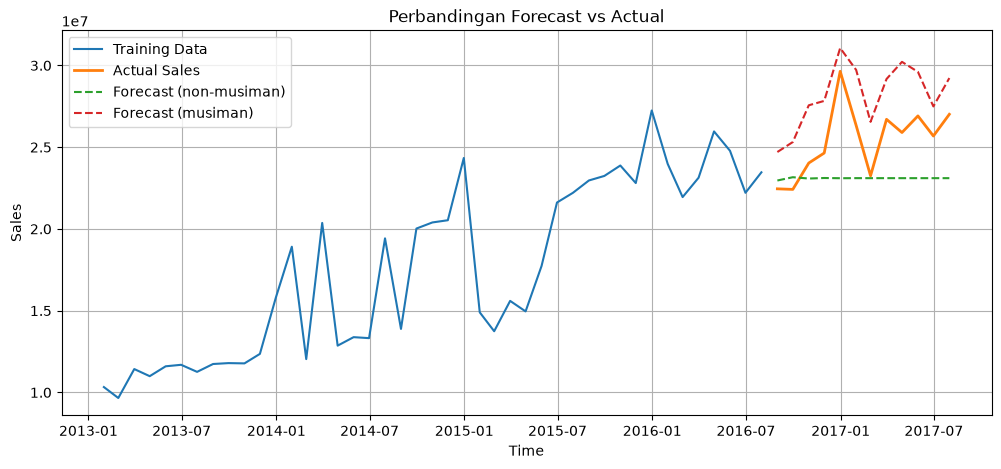

In [19]:
plt.figure(figsize=(12,5))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Sales', linewidth=2)
plt.plot(forecast, label='Forecast (non-musiman)', linestyle='--')
plt.plot(fc_seasonal, label='Forecast (musiman)', linestyle='--')
plt.title("Perbandingan Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

                             MAE        RMSE   MAPE
Seasonal Naive        1847387.08  2222531.34   7.07
Holt-Winters          2093284.44  2352632.90   8.38
Naive                 2329245.11  2829764.39   8.76
SARIMA (non-musiman)  2526611.94  3087001.18   9.46
SARIMA (musiman)      2790975.29  2897240.76  11.14

Model terbaik (MAPE terkecil): Seasonal Naive  →  7.07%


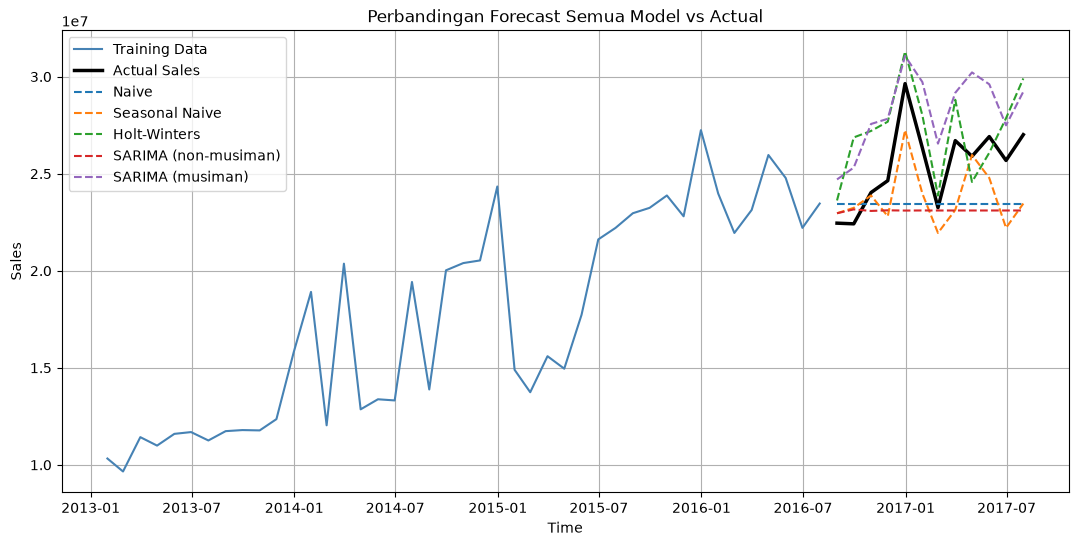

In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- fungsi error ----------
def hitung_error(test, pred):
    mae  = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))
    mape = np.mean(np.abs((test.values - np.array(pred)) / test.values)) * 100
    return mae, rmse, mape

hasil = {}
prediksi = {}   # simpan tiap forecast (sudah ber-index tanggal) buat plot

# ---------- 1. Naive ----------
pred = pd.Series(np.repeat(train.iloc[-1], len(test)), index=test.index)
prediksi['Naive'] = pred
hasil['Naive'] = hitung_error(test, pred)

# ---------- 2. Seasonal Naive (ambil 12 bln terakhir, diputar) ----------
pred = pd.Series([train.iloc[-12 + (i % 12)] for i in range(len(test))], index=test.index)
prediksi['Seasonal Naive'] = pred
hasil['Seasonal Naive'] = hitung_error(test, pred)

# ---------- 3. Holt-Winters ----------
hw = ExponentialSmoothing(train, trend='add', seasonal='add',
                          seasonal_periods=12).fit()
pred = pd.Series(hw.forecast(len(test)).values, index=test.index)
prediksi['Holt-Winters'] = pred
hasil['Holt-Winters'] = hitung_error(test, pred)

# ---------- 4. SARIMA non-musiman ----------
m1 = pm.auto_arima(train, seasonal=False,
                   error_action='ignore', suppress_warnings=True)
pred = pd.Series(m1.predict(n_periods=len(test)), index=test.index)
prediksi['SARIMA (non-musiman)'] = pred
hasil['SARIMA (non-musiman)'] = hitung_error(test, pred)

# ---------- 5. SARIMA musiman ----------
m2 = pm.auto_arima(train, seasonal=True, m=12, D=1,
                   error_action='ignore', suppress_warnings=True)
pred = pd.Series(m2.predict(n_periods=len(test)), index=test.index)
prediksi['SARIMA (musiman)'] = pred
hasil['SARIMA (musiman)'] = hitung_error(test, pred)

# ---------- tabel perbandingan ----------
tabel = pd.DataFrame(hasil, index=['MAE', 'RMSE', 'MAPE']).T.sort_values('MAPE')
print(tabel.round(2))
print(f"\nModel terbaik (MAPE terkecil): {tabel.index[0]}  →  {tabel['MAPE'].iloc[0]:.2f}%")

# ---------- plot semua model ----------
plt.figure(figsize=(13,6))
plt.plot(train, label='Training Data', color='steelblue')
plt.plot(test,  label='Actual Sales', color='black', linewidth=2.5)
for nama, pred in prediksi.items():
    plt.plot(pred, linestyle='--', label=nama)
plt.title("Perbandingan Forecast Semua Model vs Actual")
plt.xlabel("Time"); plt.ylabel("Sales")
plt.legend(); plt.grid(True)
plt.show()

# Kesimpulan
Lima model dibandingkan pada train/test split yang identik (80/20). Hasilnya, model baseline Seasonal Naive justru memberikan akurasi terbaik (MAPE 7.07%), mengungguli model yang lebih kompleks seperti Holt-Winters (8.38%) dan SARIMA (9.46%). Penambahan komponen musiman pada SARIMA malah memperburuk akurasi (11.14%), mengindikasikan overfitting akibat keterbatasan panjang data (54 observasi bulanan). Temuan ini menegaskan prinsip bahwa kompleksitas model harus sepadan dengan ukuran data; pada deret waktu pendek dengan pola musiman yang kuat dan stabil, pendekatan sederhana berbasis pola musiman tahun sebelumnya dapat lebih andal daripada model statistik canggih.

In [21]:
# Mulai dari actual, lalu tempel tiap prediksi sebagai kolom
detail = pd.DataFrame({'Actual': test})

for nama, pred in prediksi.items():
    detail[nama] = pred

print(detail.round(0).to_string())

                Actual       Naive  Seasonal Naive  Holt-Winters  SARIMA (non-musiman)  SARIMA (musiman)
date                                                                                                    
2016-08-31  22452414.0  23462672.0      22963674.0    23622585.0            22961773.0        24703705.0
2016-09-30  22417448.0  23462672.0      23240882.0    26869035.0            23161940.0        25313791.0
2016-10-31  24030390.0  23462672.0      23878268.0    27203376.0            23081950.0        27561934.0
2016-11-30  24642640.0  23462672.0      22804953.0    27679120.0            23113915.0        27829268.0
2016-12-31  29640288.0  23462672.0      27243982.0    31295578.0            23101141.0        31065745.0
2017-01-31  26328160.0  23462672.0      23977805.0    28015317.0            23106246.0        29723529.0
2017-02-28  23250112.0  23462672.0      21947409.0    23869437.0            23104206.0        26549934.0
2017-03-31  26704018.0  23462672.0      23131781.0    2

In [22]:
detail = pd.DataFrame({'Actual': test})

for nama, pred in prediksi.items():
    detail[nama] = pred
    detail[f'{nama} (selisih)'] = pred - test   # negatif = under-predict

print(detail.round(0).to_string())

                Actual       Naive  Naive (selisih)  Seasonal Naive  Seasonal Naive (selisih)  Holt-Winters  Holt-Winters (selisih)  SARIMA (non-musiman)  SARIMA (non-musiman) (selisih)  SARIMA (musiman)  SARIMA (musiman) (selisih)
date                                                                                                                                                                                                                                   
2016-08-31  22452414.0  23462672.0        1010258.0      22963674.0                  511260.0    23622585.0               1170171.0            22961773.0                        509358.0        24703705.0                   2251291.0
2016-09-30  22417448.0  23462672.0        1045224.0      23240882.0                  823434.0    26869035.0               4451587.0            23161940.0                        744492.0        25313791.0                   2896343.0
2016-10-31  24030390.0  23462672.0        -567717.0      23878268.0     

In [23]:
detail = pd.DataFrame({'Actual': test})
for nama, pred in prediksi.items():
    detail[f'{nama} (% error)'] = ((pred - test) / test * 100).round(1)
print(detail.round(0).to_string())

                Actual  Naive (% error)  Seasonal Naive (% error)  Holt-Winters (% error)  SARIMA (non-musiman) (% error)  SARIMA (musiman) (% error)
date                                                                                                                                                 
2016-08-31  22452414.0              4.0                       2.0                     5.0                             2.0                        10.0
2016-09-30  22417448.0              5.0                       4.0                    20.0                             3.0                        13.0
2016-10-31  24030390.0             -2.0                      -1.0                    13.0                            -4.0                        15.0
2016-11-30  24642640.0             -5.0                      -8.0                    12.0                            -6.0                        13.0
2016-12-31  29640288.0            -21.0                      -8.0                     6.0           

In [24]:
# Rangkai long format: tiap baris = satu tanggal, satu model, satu nilai
records = []
for tgl in test.index:
    records.append({'date': tgl, 'model': 'Actual', 'sales': test[tgl]})
    for nama, pred in prediksi.items():
        records.append({'date': tgl, 'model': nama, 'sales': pred[tgl]})

df_tableau = pd.DataFrame(records)
df_tableau.to_csv('forecast.csv', index=False)
print(df_tableau.head(12))

         date                 model         sales
0  2016-08-31                Actual  2.245241e+07
1  2016-08-31                 Naive  2.346267e+07
2  2016-08-31        Seasonal Naive  2.296367e+07
3  2016-08-31          Holt-Winters  2.362259e+07
4  2016-08-31  SARIMA (non-musiman)  2.296177e+07
5  2016-08-31      SARIMA (musiman)  2.470370e+07
6  2016-09-30                Actual  2.241745e+07
7  2016-09-30                 Naive  2.346267e+07
8  2016-09-30        Seasonal Naive  2.324088e+07
9  2016-09-30          Holt-Winters  2.686903e+07
10 2016-09-30  SARIMA (non-musiman)  2.316194e+07
11 2016-09-30      SARIMA (musiman)  2.531379e+07


In [25]:
records = []

# 1. TRAIN — beri label 'Actual' juga, supaya nyambung dengan Actual di test
for tgl in train.index:
    records.append({'date': tgl, 'model': 'Actual', 'sales': train[tgl]})

# 2. TEST actual
for tgl in test.index:
    records.append({'date': tgl, 'model': 'Actual', 'sales': test[tgl]})

# 3. Tiap forecast — sambungkan dari titik terakhir train biar nggak ada celah
titik_sambung = train.index[-1]        # tanggal terakhir train
nilai_sambung = train.iloc[-1]         # nilai terakhir train
for nama, pred in prediksi.items():
    # titik jangkar di ujung train (semua garis forecast mulai dari sini)
    records.append({'date': titik_sambung, 'model': nama, 'sales': nilai_sambung})
    # lalu nilai forecast-nya
    for tgl in test.index:
        records.append({'date': tgl, 'model': nama, 'sales': pred[tgl]})

df_tableau = pd.DataFrame(records).sort_values('date')
df_tableau.to_csv('forecast_full.csv', index=False)
print(df_tableau.head())
print(df_tableau.tail())

        date   model         sales
0 2013-01-31  Actual  1.032762e+07
1 2013-02-28  Actual  9.658960e+06
2 2013-03-31  Actual  1.142850e+07
3 2013-04-30  Actual  1.099346e+07
4 2013-05-31  Actual  1.159770e+07
          date                 model         sales
67  2017-07-31                 Naive  2.346267e+07
93  2017-07-31          Holt-Winters  2.990551e+07
80  2017-07-31        Seasonal Naive  2.346267e+07
106 2017-07-31  SARIMA (non-musiman)  2.310479e+07
119 2017-07-31      SARIMA (musiman)  2.922669e+07


In [26]:
# 1. Pilih produk unggulan (family dengan total sales terbesar)
top_family = data.groupby('family')['sales'].sum().idxmax()
print("Produk unggulan:", top_family)

# 2. Filter ke family itu, agregasi harian (jumlahkan semua toko)
df = data[data['family'] == top_family].copy()
df['date'] = pd.to_datetime(df['date'])
daily = df.groupby('date').agg({'sales':'sum', 'onpromotion':'sum'})

# 3. Feature engineering — ini inti regresi bergandanya
daily['dayofweek'] = daily.index.dayofweek      # 0=Senin ... 6=Minggu
daily['month']     = daily.index.month
daily['lag_1']     = daily['sales'].shift(1)     # sales kemarin
daily['lag_7']     = daily['sales'].shift(7)     # sales minggu lalu (hari sama)
daily = daily.dropna()

# 4. Split urut waktu (JANGAN acak)
n = len(daily)
train = daily[:int(n*0.8)]
test  = daily[int(n*0.8):]

# 5. Regresi berganda
from sklearn.linear_model import LinearRegression
fitur = ['onpromotion','dayofweek','month','lag_1','lag_7']
model = LinearRegression().fit(train[fitur], train['sales'])
pred  = model.predict(test[fitur])

# 6. Evaluasi + lihat koefisien (mana yang paling ngaruh)
print(dict(zip(fitur, model.coef_.round(2))))

Produk unggulan: GROCERY I
{'onpromotion': np.float64(5.89), 'dayofweek': np.float64(11296.93), 'month': np.float64(935.93), 'lag_1': np.float64(0.59), 'lag_7': np.float64(0.18)}


In [27]:
# ============ CELL 1: pilih produk unggulan + agregasi harian ============
import numpy as np
import pandas as pd

data['date'] = pd.to_datetime(data['date'])

# produk unggulan = family dengan total sales terbesar
top_family = data.groupby('family')['sales'].sum().idxmax()
print("Produk unggulan:", top_family)

# filter ke family itu, agregasi harian (total semua toko)
df = data[data['family'] == top_family].copy()
daily = df.groupby('date').agg(sales=('sales','sum'),
                               onpromotion=('onpromotion','sum')).sort_index()

# rapikan ke frekuensi harian penuh (isi kalau ada tanggal bolong)
daily = daily.asfreq('D')
daily['sales'] = daily['sales'].interpolate()
daily['onpromotion'] = daily['onpromotion'].fillna(0)

print(daily.shape)
daily.head()

Produk unggulan: GROCERY I
(1688, 2)


,sales,onpromotion
date,,
2013-01-01,700.0,0.0
2013-01-02,202020.0,0.0
2013-01-03,144878.0,0.0
2013-01-04,135754.0,0.0
2013-01-05,188356.0,0.0


In [28]:
# ============ CELL 2: feature engineering ============
d = daily.copy()

# fitur kalender
d['dayofweek'] = d.index.dayofweek        # 0=Senin ... 6=Minggu
d['month']     = d.index.month

# fitur lag — ini yang menangani autokorelasi
d['lag_1'] = d['sales'].shift(1)          # kemarin
d['lag_7'] = d['sales'].shift(7)          # hari sama minggu lalu

# one-hot encoding untuk kategori (INI perbaikan pentingnya)
d = pd.get_dummies(d, columns=['dayofweek','month'], drop_first=True)

# get_dummies keluar bool di pandas baru -> ubah ke int biar aman
bool_cols = d.select_dtypes('bool').columns
d[bool_cols] = d[bool_cols].astype(int)

d = d.dropna()   # buang baris awal yang lag-nya NaN
print(d.shape)

(1681, 21)


In [29]:
# ============ CELL 3: split urut waktu + daftar fitur ============
n = len(d); split = int(n*0.8)
train = d.iloc[:split]
test  = d.iloc[split:]

fitur = [c for c in d.columns if c != 'sales']   # onpromotion, lag, semua dummy

print(f"Train: {len(train)} hari ({train.index.min().date()} - {train.index.max().date()})")
print(f"Test : {len(test)} hari ({test.index.min().date()} - {test.index.max().date()})")

Train: 1344 hari (2013-01-08 - 2016-09-12)
Test : 337 hari (2016-09-13 - 2017-08-15)


In [32]:
# ============ CELL 4: fungsi error ============
from sklearn.metrics import mean_absolute_error, mean_squared_error

def hitung_error(actual, pred):
    actual = np.asarray(actual, float); pred = np.asarray(pred, float)
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mask = actual != 0                       # guard MAPE dari bagi nol
    mape = np.mean(np.abs((actual[mask]-pred[mask])/actual[mask]))*100
    return mae, rmse, mape

hasil = {}; prediksi = {}

In [33]:
# ============ CELL 5: baseline ============
# Naive: nilai kemarin
prediksi['Naive'] = test['lag_1']
hasil['Naive'] = hitung_error(test['sales'], test['lag_1'])

# Seasonal Naive mingguan: nilai 7 hari lalu
prediksi['Seasonal Naive (7h)'] = test['lag_7']
hasil['Seasonal Naive (7h)'] = hitung_error(test['sales'], test['lag_7'])

In [34]:
# ============ CELL 6: REGRESI BERGANDA (bintang utamanya) ============
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(train[fitur], train['sales'])
pred = pd.Series(lr.predict(test[fitur]), index=test.index)
prediksi['Regresi Berganda'] = pred
hasil['Regresi Berganda'] = hitung_error(test['sales'], pred)

# koefisien — mana prediktor paling berpengaruh (nilai jual regresi vs ARIMA)
koef = pd.Series(lr.coef_, index=fitur).sort_values(key=abs, ascending=False)
print("Pengaruh terkuat:")
print(koef.head(8).round(2))

Pengaruh terkuat:
dayofweek_5    95677.02
dayofweek_6    72199.57
dayofweek_4    40335.04
dayofweek_2    32023.50
month_12       24639.69
dayofweek_1    23301.00
dayofweek_3    16428.76
month_10        6704.68
dtype: float64


In [35]:
# ============ CELL 7: SARIMAX = regresi + ARIMA (onpromotion sbg exog) ============
# ⚠️ PELAN — auto_arima di data harian bisa makan 1-3 menit. Sabar.
import pmdarima as pm

sarimax = pm.auto_arima(train['sales'], X=train[['onpromotion']],
                        seasonal=True, m=7, D=1,
                        error_action='ignore', suppress_warnings=True,
                        stepwise=True, trace=False)
print(sarimax.summary())

pred = pd.Series(sarimax.predict(n_periods=len(test), X=test[['onpromotion']]),
                 index=test.index)
prediksi['SARIMAX (+promo)'] = pred
hasil['SARIMAX (+promo)'] = hitung_error(test['sales'], pred)

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1344
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 7)   Log Likelihood              -15625.037
Date:                             Wed, 01 Jul 2026   AIC                          31260.075
Time:                                     10:11:45   BIC                          31286.065
Sample:                                 01-08-2013   HQIC                         31269.813
                                      - 09-12-2016                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept    1082.5845    174.143      6.217      0.000     741.271    1423.898
onpromotion    10.5251  

                          MAE      RMSE   MAPE
Regresi Berganda     24486.72  39432.00  52.35
Naive                44126.59  61244.12  61.27
Seasonal Naive (7h)  38550.07  58008.11  67.39
SARIMAX (+promo)     77054.01  88868.04  80.15

Terbaik (MAPE): Regresi Berganda → 52.35%


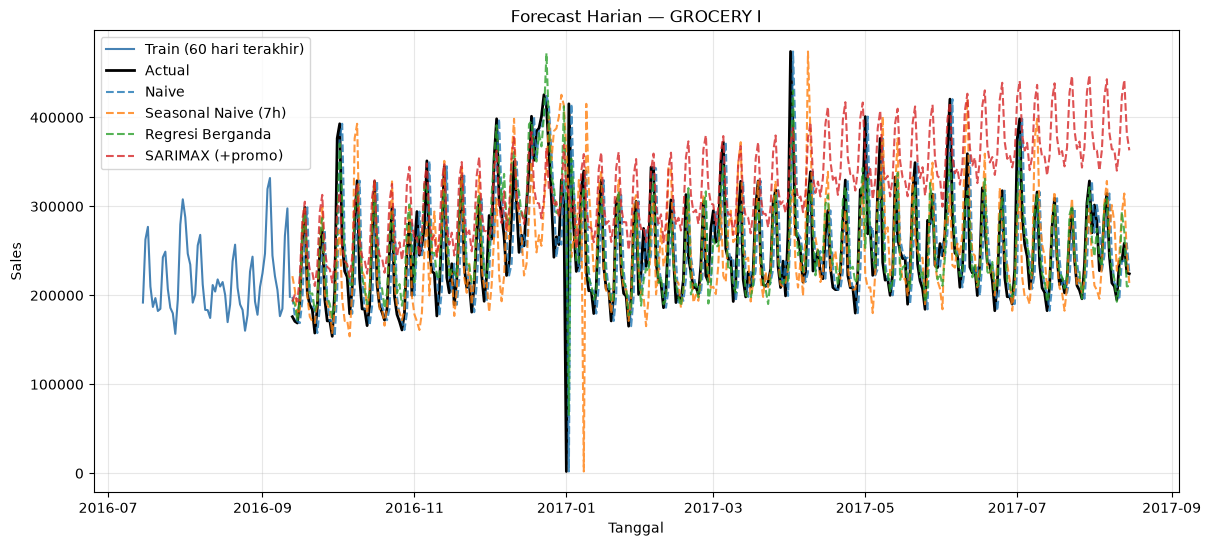

In [36]:
# ============ CELL 8: tabel + plot ============
tabel = pd.DataFrame(hasil, index=['MAE','RMSE','MAPE']).T.sort_values('MAPE')
print(tabel.round(2))
print(f"\nTerbaik (MAPE): {tabel.index[0]} → {tabel['MAPE'].iloc[0]:.2f}%")

import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(train['sales'].iloc[-60:], label='Train (60 hari terakhir)', color='steelblue')
plt.plot(test['sales'], label='Actual', color='black', linewidth=2)
for nama, p in prediksi.items():
    plt.plot(p, linestyle='--', alpha=0.8, label=nama)
plt.title(f"Forecast Harian — {top_family}")
plt.xlabel("Tanggal"); plt.ylabel("Sales"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [37]:
records = []

# Actual penuh: train + test (biar garis membentang, bukan mengambang)
for tgl in train.index:
    records.append({'date': tgl, 'model': 'Actual', 'sales': train.loc[tgl, 'sales']})
for tgl in test.index:
    records.append({'date': tgl, 'model': 'Actual', 'sales': test.loc[tgl, 'sales']})

# Forecast tiap model — dijangkar di titik akhir train biar nyambung
titik, nilai = train.index[-1], train['sales'].iloc[-1]
for nama, pred in prediksi.items():
    records.append({'date': titik, 'model': nama, 'sales': nilai})
    for tgl in test.index:
        records.append({'date': tgl, 'model': nama, 'sales': pred[tgl]})

pd.DataFrame(records).sort_values('date').to_csv('forecast_harian.csv', index=False)
print("Tersimpan: forecast_harian.csv")

Tersimpan: forecast_harian.csv


In [38]:
# Pakai model TERBAIK dari backtesting. Ganti sesuai pemenangmu.
# Contoh: SARIMAX. Latih ulang di SELURUH data harian.
import pmdarima as pm

full = d['sales']                    # seluruh data, tanpa sisakan test
full_exog = d[['onpromotion']]

model_final = pm.auto_arima(full, X=full_exog, seasonal=True, m=7, D=1,
                            error_action='ignore', suppress_warnings=True)

# Ramal 30 hari ke depan (butuh asumsi onpromotion masa depan)
H = 30
future_promo = pd.DataFrame({'onpromotion': [0]*H})   # asumsi: tak ada promo
future_pred = model_final.predict(n_periods=H, X=future_promo)

# Beri tanggal masa depan
future_idx = pd.date_range(d.index[-1] + pd.Timedelta(days=1), periods=H, freq='D')
future = pd.Series(future_pred, index=future_idx)

# Ekspor untuk Tableau — label 'Forecast' biar beda dari Actual
rec = [{'date': t, 'model': 'Actual', 'sales': v} for t, v in d['sales'].items()]
rec += [{'date': t, 'model': 'Forecast', 'sales': v} for t, v in future.items()]
# jangkar biar nyambung
rec.append({'date': d.index[-1], 'model': 'Forecast', 'sales': d['sales'].iloc[-1]})

pd.DataFrame(rec).sort_values('date').to_csv('forecast_future.csv', index=False)
print(f"Meramal {H} hari ke depan, sampai {future_idx[-1].date()}")

Meramal 30 hari ke depan, sampai 2017-09-14


In [39]:
# Berapa hari yang sales-nya kecil/nol di test?
print("Sales test terkecil:")
print(test['sales'].nsmallest(10))
print(f"\nJumlah hari sales < 1000: {(test['sales'] < 1000).sum()}")
print(f"Jumlah hari sales == 0  : {(test['sales'] == 0).sum()}")

# Lihat apakah ada 1-2 hari yang MAPE-nya ekstrem (buat Regresi)
err = np.abs((test['sales'] - prediksi['Regresi Berganda']) / test['sales']) * 100
print("\n10 hari dengan % error terbesar:")
print(err.nlargest(10).round(0))

Sales test terkecil:
date
2017-01-01      1998.000
2016-09-29    153914.398
2016-09-22    157583.834
2016-10-27    161035.113
2017-01-26    165307.223
2016-10-13    165917.540
2016-09-15    168851.383
2016-10-26    170707.000
2016-09-14    170787.774
2017-01-19    171175.212
Name: sales, dtype: float64

Jumlah hari sales < 1000: 0
Jumlah hari sales == 0  : 0

10 hari dengan % error terbesar:
date
2017-01-01    14531.0
2017-01-02       84.0
2017-02-26       43.0
2017-05-01       37.0
2016-12-31       36.0
2016-12-27       32.0
2017-02-19       32.0
2017-04-01       32.0
2017-05-26       28.0
2017-05-14       28.0
dtype: float64


In [40]:
# Hitung ulang error TANPA hari libur ekstrem (1 Jan)
mask = test['sales'] > 50000   # buang hari tutup/libur volume rendah

for nama, pred in prediksi.items():
    a = test['sales'][mask]; p = pred[mask]
    mape = np.mean(np.abs((a - p) / a)) * 100
    print(f"{nama:22s} MAPE (tanpa libur): {mape:.2f}%")

Naive                  MAPE (tanpa libur): 16.72%
Seasonal Naive (7h)    MAPE (tanpa libur): 14.05%
Regresi Berganda       MAPE (tanpa libur): 9.25%
SARIMAX (+promo)       MAPE (tanpa libur): 32.67%


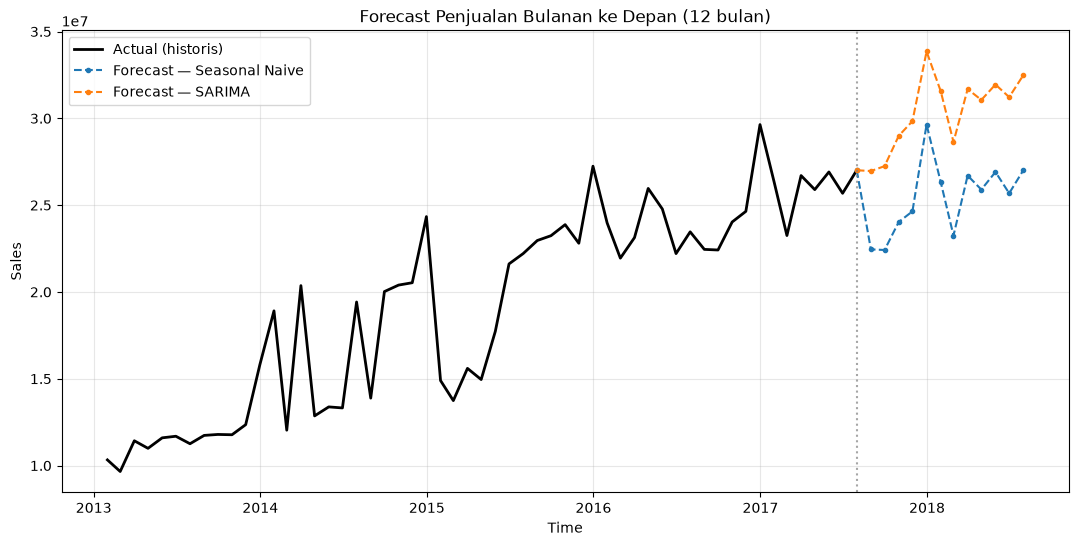

Ramalan 12 bulan ke depan, sampai 2018-07-31


In [41]:
# ============ Forecast BULANAN ke depan ============
H = 12   # ramal 12 bulan ke depan (Sep 2017 - Ags 2018)

# titik awal masa depan: sebulan setelah data terakhir
future_idx = pd.date_range(monthly_group.index[-1] + pd.offsets.MonthEnd(1),
                           periods=H, freq='ME')

masa_depan = {}

# --- 1. Seasonal Naive (pemenang backtesting) — salin 12 bln terakhir ---
last_12 = monthly_group.iloc[-12:].values
masa_depan['Seasonal Naive'] = pd.Series(
    [last_12[i % 12] for i in range(H)], index=future_idx)

# --- 2. SARIMA (dilatih ulang di SELURUH data) sbg pembanding ---
m_final = pm.auto_arima(monthly_group, seasonal=True, m=12, D=1,
                        error_action='ignore', suppress_warnings=True)
masa_depan['SARIMA'] = pd.Series(
    m_final.predict(n_periods=H), index=future_idx)

# --- plot: historis + forecast ke depan ---
plt.figure(figsize=(13,6))
plt.plot(monthly_group, label='Actual (historis)', color='black', linewidth=2)
for nama, fc in masa_depan.items():
    # jangkar di titik terakhir historis biar garis nyambung
    fc_sambung = pd.concat([pd.Series(monthly_group.iloc[-1],
                            index=[monthly_group.index[-1]]), fc])
    plt.plot(fc_sambung, linestyle='--', marker='o', markersize=3, label=f'Forecast — {nama}')
plt.axvline(monthly_group.index[-1], color='gray', linestyle=':', alpha=0.7)
plt.title("Forecast Penjualan Bulanan ke Depan (12 bulan)")
plt.xlabel("Time"); plt.ylabel("Sales")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# --- ekspor buat Tableau ---
rec = [{'date': t, 'model': 'Actual', 'sales': v} for t, v in monthly_group.items()]
for nama, fc in masa_depan.items():
    rec.append({'date': monthly_group.index[-1], 'model': nama,
                'sales': monthly_group.iloc[-1]})   # jangkar
    rec += [{'date': t, 'model': nama, 'sales': v} for t, v in fc.items()]

pd.DataFrame(rec).sort_values('date').to_csv('forecast_bulanan_future.csv', index=False)
print(f"Ramalan {H} bulan ke depan, sampai {future_idx[-1].date()}")

In [42]:
from sklearn.linear_model import LinearRegression

dampak = {}
for fam in data['family'].unique():
    sub = data[data['family'] == fam]
    daily = sub.groupby('date').agg(sales=('sales','sum'),
                                    promo=('onpromotion','sum'))
    if daily['promo'].sum() == 0 or len(daily) < 30:
        continue
    lr = LinearRegression().fit(daily[['promo']], daily['sales'])
    dampak[fam] = lr.coef_[0]   # kenaikan sales per unit promosi

ranking = pd.Series(dampak).sort_values(ascending=False)
print("Dampak promosi terhadap sales (β) per family:")
print(ranking.head(10).round(1))

Dampak promosi terhadap sales (β) per family:
BEVERAGES                     50.2
GROCERY I                     21.1
HOME CARE                     20.4
PRODUCE                       20.0
FROZEN FOODS                  19.3
LIQUOR,WINE,BEER              15.4
PET SUPPLIES                  13.7
SCHOOL AND OFFICE SUPPLIES    12.3
HOME AND KITCHEN II           11.6
MAGAZINES                     10.4
dtype: float64
